# 多层感知机
最简单的**深度网络**就是多层感知机，由多层神经元堆砌而成，每层神经元从上一层
获得输入处理后传递给下一层。

## 多层感知机（简介）
### 隐藏层
#### 线性模型可能会出错
第三章做的尝试局限于仿射变换，而仿射变换里的**线性**是一个很特殊的假设。
事实上线性模型很容易出错，因为实际上很多问题特征与结果并不呈线性关系，
比如人高于37°C和低于37°C都容易增加患病风险，但是线性模型就不太方便处理这样的问题，
这时需要人工手动设计一个取绝对值的环节，模型才更容易处理。

但如果是更复杂的问题比如图像处理问题，
我改动一个像素点是否总是增加结果A的概率减少结果B的概率呢？这并不好确定。
此时就需要单独开一层来处理这个问题，把它转化成后续模型好处理的形式。

实际问题中，特征与结果的关系是极其复杂的，取决于很多因素，
比如图像中表现一个暗点需要周围像素的衬托。这个时候就需要隐藏层对数据进行一定处理，
把原始数据处理成后续神经元好处理的形式。

隐藏层需要在数据中学习如何表示数据，同时，输出层也需要跟着隐藏层一起学习，
好适应如何处理隐藏层传给自己的数据，做出最后合适的判断。

#### 加入隐藏层
想象多层感知机的架构，一个堆砌若干个全连接层的神经网络，
除了最后一层是可以被视作线性预测器输出层外，
前面是大小不一形态各异的隐藏层堆叠形成。

显然，对于这个架构，存在一个问题，即多层隐藏层会导致参数量极高，而且即使我们付出了增加参数量的代价，
但是仿射变换x仿射变换->仿射变换，仍然没有跳脱这个圈，若干层仿射变换总是相当于一层仿射变换，
这样做似乎没有意义？

#### 从线性到非线性
为了避免多个仿射变换的隐藏层堆叠被退化成单层仿射变换，我们需要对每一层仿射变换的隐藏层做特殊处理。
我们需要一个激活函数$\sigma{()}$，
使之前的隐藏层$\mathbf{H_{before}} = \mathbf{X}\mathbf{W}+\mathbf{b}$变成
$\mathbf{H} = \sigma{(\mathbf{X}\mathbf{W}+\mathbf{b})}$。一般来说，只要你的激活函数$\sigma$不要太差劲（硬性要求：非线性），
这个隐藏层网络就不会退化成单层仿射变换了。

#### 通用近似定理
隐藏层可以通过切分捕捉输入间的关系，因此其能模拟任何函数对输入的处理方式，即理论上隐藏层能对任一函数建模。
但遗憾的是，这只是存在于理论上，实际上要训练一个隐藏层网络使之拟合某个复杂函数并不简单。

同时，理论上单层隐藏层也能实现类似效果，但是这样做会非常难训练。
因此我们通常使用更多隐藏层堆叠而非使用一个巨大的隐藏层去拟合我们期望的目标函数。

### 激活函数
这就是上文说到的$\sigma$，其是DL的基础，以下介绍一些激活函数

In [5]:
import torch
from d2l import torch as d2l

#### ReLU函数
ReLU = **Re**ctified **L**inear **U**nit，修正线性单元
$$ReLU(X) = \max{(x, 0)}$$
就是这么朴实无华

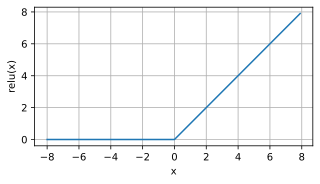

In [6]:
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.relu(x)
d2l.plot(x.detach(), y.detach(), 'x', 'relu(x)', figsize=(5, 2.5))

```python
y.backward(torch.ones_like(x), retain_graph=True)
```
求导长什么样似乎不必多说，但是很简单能看出来，这个函数的导函数极其简单，0以下是0，0以上是1，0不可导，简单的微积分知识。

这个激活函数非常好的一点在于，无论是它的导数还是他的函数值都有一个阀门的特性，要不全过要不全不过，这使得其优化表现很好。

ReLU还有一个变体 参数化ReLU ，允许参数小于0时也能有数据通过，类似这样
$$pReLU(x) = \max{(0, x)} + \alpha\min{(0, x)}$$

#### sigmoid函数
有时我们希望把一个范围为R的数压缩到(0, 1)中去，这个时候可以利用反比例函数和指数函数的性质，类似
$$sigmoid(x)=\frac{1}{1+\exp{(-x)}}$$
一般称sigmoid这种函数为 挤压（squashing）函数 。注意这里的exp理论上底数可以是任何大于1的数，但是一般使用e的原因是因为导数比较简单，
同时跟softmax、交叉熵等也比较般配

想象这样一个函数
$$f(x)=
\begin{cases}
1 & x > 0\\
0 & x < 0
\end{cases}$$
显然，在0附近存在两个问题：过度太生硬，0处不可导。

但是，sigmoid可以较为完美解决这个问题。

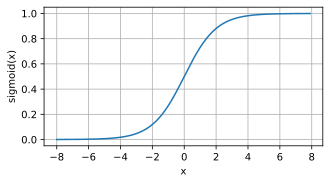

In [7]:
y = torch.sigmoid(x)
d2l.plot(x.detach(), y.detach(), 'x', 'sigmoid(x)', figsize=(5, 2.5))

不过现在越来越多人去使用ReLU代替这个函数了。
顺带一提，以下为其导数公式：
$$\frac{d}{dx} \operatorname{sigmoid}(x) = \frac{\exp(-x)}{(1 + \exp(-x))^2} = \operatorname{sigmoid}(x)\left(1-\operatorname{sigmoid}(x)\right).$$


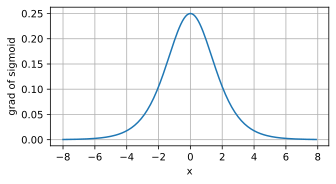

In [ ]:
y.backward(torch.ones_like(x),retain_graph=True)
d2l.plot(x.detach(), x.grad, 'x', 'grad of sigmoid', figsize=(5, 2.5))

#### tanh函数
$\tanh(x)$，即双曲正切，微积分的老朋友，图像跟sigmoid有点像，不同的是sigmoid关于(0, 0.5)对称，而tanh关于原点对称，同时tanh在原点处更趋近线性。

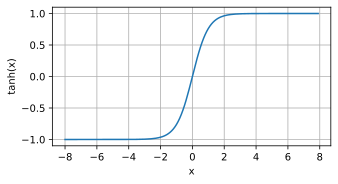

In [13]:
# 函数图像
y = torch.tanh(x)
d2l.plot(x.detach(), y.detach(), 'x', 'tanh(x)', figsize=(5, 2.5))

其导数公式为
$$\frac{d}{dx} \operatorname{tanh}(x) = 1 - \operatorname{tanh}^2(x).$$

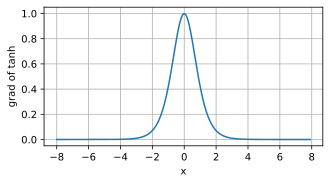

In [14]:
# 清除以前的梯度
x.grad.data.zero_()
y.backward(torch.ones_like(x),retain_graph=True)
d2l.plot(x.detach(), x.grad, 'x', 'grad of tanh', figsize=(5, 2.5))

补一句，$\tanh(x)+1=2sigmoid(2x)$

## 多层感知机的从零实现
以下会继续使用MNIST数据集，以方便对比Softmax分类与MLP的区别

In [ ]:
from torch import nn
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)